In [14]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [15]:
# set project paths
BASE_DIR = Path.cwd().parent

DATASET_DIR = BASE_DIR / "datasets"

OUTPUT_DIR = BASE_DIR / "outputs"

OUTPUT_DIR.mkdir(exist_ok=True)

In [16]:
# create a transaction dataset
transactions = {

    "transaction_id": [1001,1002,1003,1004,1005,1006,1007,1008],

    "customer_name": [
        "John",
        "Mary",
        "David",
        "Sarah",
        "Mike",
        "John",
        "Mary",
        "David"
    ],

    "branch": [
        "Nairobi",
        "Mombasa",
        "Nairobi",
        "Kisumu",
        "Nakuru",
        "Nairobi",
        "Mombasa",
        "Nairobi"
    ],

    "transaction_amount": [
        45000,
        120000,
        np.nan,
        98000,
        52000,
        67000,
        150000,
        72000
    ],

    "transaction_date": [
        "2026-05-15",
        "2026-05-16",
        "2026-05-16",
        "2026-05-17",
        "2026-05-18",
        "2026-05-18",
        "2026-05-19",
        "2026-05-20"
    ]
}

df = pd.DataFrame(transactions)

df

,transaction_id,customer_name,branch,transaction_amount,transaction_date
0,1001,John,Nairobi,45000.0,2026-05-15
1,1002,Mary,Mombasa,120000.0,2026-05-16
2,1003,David,Nairobi,NaN,2026-05-16
3,1004,Sarah,Kisumu,98000.0,2026-05-17
4,1005,Mike,Nakuru,52000.0,2026-05-18
5,1006,John,Nairobi,67000.0,2026-05-18
6,1007,Mary,Mombasa,150000.0,2026-05-19
7,1008,David,Nairobi,72000.0,2026-05-20


In [17]:
# convert dates to datetime format
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"]
)

#recheck the dataset
df.head()

,transaction_id,customer_name,branch,transaction_amount,transaction_date
0,1001,John,Nairobi,45000.0,2026-05-15
1,1002,Mary,Mombasa,120000.0,2026-05-16
2,1003,David,Nairobi,NaN,2026-05-16
3,1004,Sarah,Kisumu,98000.0,2026-05-17
4,1005,Mike,Nakuru,52000.0,2026-05-18


In [18]:
#extract date features
#extract month
df["month"] = df["transaction_date"].dt.month
df


,transaction_id,customer_name,branch,transaction_amount,transaction_date,month
0,1001,John,Nairobi,45000.0,2026-05-15,5
1,1002,Mary,Mombasa,120000.0,2026-05-16,5
2,1003,David,Nairobi,NaN,2026-05-16,5
3,1004,Sarah,Kisumu,98000.0,2026-05-17,5
4,1005,Mike,Nakuru,52000.0,2026-05-18,5
5,1006,John,Nairobi,67000.0,2026-05-18,5
6,1007,Mary,Mombasa,150000.0,2026-05-19,5
7,1008,David,Nairobi,72000.0,2026-05-20,5


In [19]:
#extract year
df["year"] = df["transaction_date"].dt.year
df

,transaction_id,customer_name,branch,transaction_amount,transaction_date,month,year
0,1001,John,Nairobi,45000.0,2026-05-15,5,2026
1,1002,Mary,Mombasa,120000.0,2026-05-16,5,2026
2,1003,David,Nairobi,NaN,2026-05-16,5,2026
3,1004,Sarah,Kisumu,98000.0,2026-05-17,5,2026
4,1005,Mike,Nakuru,52000.0,2026-05-18,5,2026
5,1006,John,Nairobi,67000.0,2026-05-18,5,2026
6,1007,Mary,Mombasa,150000.0,2026-05-19,5,2026
7,1008,David,Nairobi,72000.0,2026-05-20,5,2026


In [20]:
#extract day name
df["day_name"] = df["transaction_date"].dt.day_name()
df

,transaction_id,customer_name,branch,transaction_amount,transaction_date,month,year,day_name
0,1001,John,Nairobi,45000.0,2026-05-15,5,2026,Friday
1,1002,Mary,Mombasa,120000.0,2026-05-16,5,2026,Saturday
2,1003,David,Nairobi,NaN,2026-05-16,5,2026,Saturday
3,1004,Sarah,Kisumu,98000.0,2026-05-17,5,2026,Sunday
4,1005,Mike,Nakuru,52000.0,2026-05-18,5,2026,Monday
5,1006,John,Nairobi,67000.0,2026-05-18,5,2026,Monday
6,1007,Mary,Mombasa,150000.0,2026-05-19,5,2026,Tuesday
7,1008,David,Nairobi,72000.0,2026-05-20,5,2026,Wednesday


In [21]:
#check missing values
df.isnull().sum()

transaction_id        0
customer_name         0
branch                0
transaction_amount    1
transaction_date      0
month                 0
year                  0
day_name              0
dtype: int64

In [22]:
#Now let's fill the missing values in the transaction_amount column
#The first option is to fill the missing values with the mean of the column
df["transaction_amount"] = df[
    "transaction_amount"
].fillna(
    df["transaction_amount"].mean()
)
df

,transaction_id,customer_name,branch,transaction_amount,transaction_date,month,year,day_name
0,1001,John,Nairobi,45000.000000,2026-05-15,5,2026,Friday
1,1002,Mary,Mombasa,120000.000000,2026-05-16,5,2026,Saturday
2,1003,David,Nairobi,86285.714286,2026-05-16,5,2026,Saturday
3,1004,Sarah,Kisumu,98000.000000,2026-05-17,5,2026,Sunday
4,1005,Mike,Nakuru,52000.000000,2026-05-18,5,2026,Monday
5,1006,John,Nairobi,67000.000000,2026-05-18,5,2026,Monday
6,1007,Mary,Mombasa,150000.000000,2026-05-19,5,2026,Tuesday
7,1008,David,Nairobi,72000.000000,2026-05-20,5,2026,Wednesday


In [23]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [24]:
#create a duplicate intentionally
df = pd.concat([df, df.iloc[[0]]])

df

,transaction_id,customer_name,branch,transaction_amount,transaction_date,month,year,day_name
0,1001,John,Nairobi,45000.000000,2026-05-15,5,2026,Friday
1,1002,Mary,Mombasa,120000.000000,2026-05-16,5,2026,Saturday
2,1003,David,Nairobi,86285.714286,2026-05-16,5,2026,Saturday
3,1004,Sarah,Kisumu,98000.000000,2026-05-17,5,2026,Sunday
4,1005,Mike,Nakuru,52000.000000,2026-05-18,5,2026,Monday
5,1006,John,Nairobi,67000.000000,2026-05-18,5,2026,Monday
6,1007,Mary,Mombasa,150000.000000,2026-05-19,5,2026,Tuesday
7,1008,David,Nairobi,72000.000000,2026-05-20,5,2026,Wednesday
0,1001,John,Nairobi,45000.000000,2026-05-15,5,2026,Friday


In [25]:
#Now let's recheck again
df.duplicated().sum()

np.int64(1)

In [27]:
#Now let's remove the duplicates
df = df.drop_duplicates()
df


,transaction_id,customer_name,branch,transaction_amount,transaction_date,month,year,day_name
0,1001,John,Nairobi,45000.000000,2026-05-15,5,2026,Friday
1,1002,Mary,Mombasa,120000.000000,2026-05-16,5,2026,Saturday
2,1003,David,Nairobi,86285.714286,2026-05-16,5,2026,Saturday
3,1004,Sarah,Kisumu,98000.000000,2026-05-17,5,2026,Sunday
4,1005,Mike,Nakuru,52000.000000,2026-05-18,5,2026,Monday
5,1006,John,Nairobi,67000.000000,2026-05-18,5,2026,Monday
6,1007,Mary,Mombasa,150000.000000,2026-05-19,5,2026,Tuesday
7,1008,David,Nairobi,72000.000000,2026-05-20,5,2026,Wednesday


In [28]:
#Now le's analyze the branches
branch_analysis = df.groupby("branch").agg({

    "transaction_amount": [
        "sum",
        "mean",
        "max",
        "min"
    ],

    "transaction_id": "count"

})

branch_analysis

transaction_amount                                          \
                       sum           mean            max       min   
branch                                                               
Kisumu        98000.000000   98000.000000   98000.000000   98000.0   
Mombasa      270000.000000  135000.000000  150000.000000  120000.0   
Nairobi      270285.714286   67571.428571   86285.714286   45000.0   
Nakuru        52000.000000   52000.000000   52000.000000   52000.0   

        transaction_id  
                 count  
branch                  
Kisumu               1  
Mombasa              2  
Nairobi              4  
Nakuru               1

In [29]:
#let's clean column names
branch_analysis.columns = [

    "total_transactions",
    "average_transaction",
    "highest_transaction",
    "lowest_transaction",
    "transaction_count"

]

branch_analysis

,total_transactions,average_transaction,highest_transaction,lowest_transaction,transaction_count
branch,,,,,
Kisumu,98000.000000,98000.000000,98000.000000,98000.0,1
Mombasa,270000.000000,135000.000000,150000.000000,120000.0,2
Nairobi,270285.714286,67571.428571,86285.714286,45000.0,4
Nakuru,52000.000000,52000.000000,52000.000000,52000.0,1


In [30]:
#let's sort the branches by total transactions
branch_analysis.sort_values(
    by="total_transactions",
    ascending=False
)

,total_transactions,average_transaction,highest_transaction,lowest_transaction,transaction_count
branch,,,,,
Nairobi,270285.714286,67571.428571,86285.714286,45000.0,4
Mombasa,270000.000000,135000.000000,150000.000000,120000.0,2
Kisumu,98000.000000,98000.000000,98000.000000,98000.0,1
Nakuru,52000.000000,52000.000000,52000.000000,52000.0,1


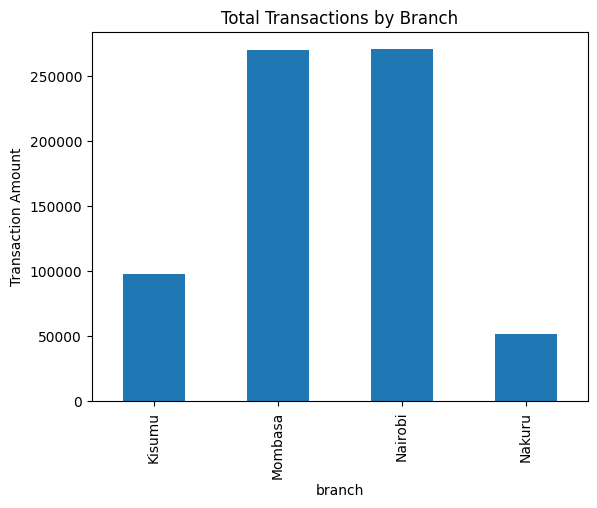

In [31]:
#let's visualize the total transaction amount by branch
branch_analysis["total_transactions"].plot(
    kind="bar"
)

plt.title("Total Transactions by Branch")

plt.ylabel("Transaction Amount")

plt.show()

In [32]:
#Fraud and Anomaly Detection
#lets now simulate transaction review logic
df["review_flag"] = np.where(

    df["transaction_amount"] > 100000,

    "Investigate",

    "Normal"

)

df

,transaction_id,customer_name,branch,transaction_amount,transaction_date,month,year,day_name,review_flag
0,1001,John,Nairobi,45000.000000,2026-05-15,5,2026,Friday,Normal
1,1002,Mary,Mombasa,120000.000000,2026-05-16,5,2026,Saturday,Investigate
2,1003,David,Nairobi,86285.714286,2026-05-16,5,2026,Saturday,Normal
3,1004,Sarah,Kisumu,98000.000000,2026-05-17,5,2026,Sunday,Normal
4,1005,Mike,Nakuru,52000.000000,2026-05-18,5,2026,Monday,Normal
5,1006,John,Nairobi,67000.000000,2026-05-18,5,2026,Monday,Normal
6,1007,Mary,Mombasa,150000.000000,2026-05-19,5,2026,Tuesday,Investigate
7,1008,David,Nairobi,72000.000000,2026-05-20,5,2026,Wednesday,Normal


In [33]:
#let's now export the cleaned dataset
df.to_csv(
    "../datasets/day_2_transactions.csv",
    index=False
)